In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap
import pacmap
import pandas as pd
import numpy as np

import sys
import os

import unsupervizedClass
from models.unsupervised.dimReduction.dReduce import *

/home/hootdarcy/ChE7700/che7700env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1772920049.344953   26437 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772920049.345381   26437 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772920049.380001   26437 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler 

In [2]:
data = unsupervizedClass.DataPreprocessing()
data = data.load_data('/home/hootdarcy/ChE7700/Stocks_Project/scripts/data/World-Stock-Prices-Dataset.csv')

labels = data[:,6:7]
print(labels)
data = data[:,0:6]
print(data)

dataDateFloat = data[:,0].astype('datetime64[s]').astype(float)
data[:,0] = dataDateFloat


scaler = StandardScaler().fit(data)
dataScaled = scaler.transform(data)

X_train,X_test,Y_train,Y_test = train_test_split( dataScaled, labels, test_size=0.15)

#hueYtrain = pd.DataFrame({'x': x_data, 'y': y_data, 'category': Y_train})
#hueYtest = pd.DataFrame({'x': x_data, 'y': y_data, 'category': Y_test})

# num_samples = dataScaled.shape[0]
# train_proportion = 0.7
# val_proportion = 0.15
# test_proportion = 0.15

# num_train = int(num_samples * train_proportion)
# num_val = int(num_samples * val_proportion)


# indices = np.arange(num_samples)
# np.random.seed(42) 
# np.random.shuffle(indices)

# train_indices = indices[:num_train]
# val_indices = indices[num_train:num_train + num_val]
# test_indices = indices[num_train + num_val:]

# train_data = dataScaled[train_indices]
# val_data = dataScaled[val_indices]
# test_data = dataScaled[test_indices]


print(f"Train data shape: {X_train.shape}")
print(f"Test data shape: {Y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test data shape: {Y_test.shape}")

                        Date        Open        High         Low       Close  \
0  2025-07-03 00:00:00-04:00    6.630000    6.740000    6.615000    6.640000   
1  2025-07-03 00:00:00-04:00  106.750000  108.370003  106.330101  107.339996   
2  2025-07-03 00:00:00-04:00  122.629997  123.050003  121.550003  121.930000   
3  2025-07-03 00:00:00-04:00  221.705002  224.009995  221.360001  223.410004   
4  2025-07-03 00:00:00-04:00  212.145004  214.649994  211.810104  213.550003   

     Volume Brand_Name Ticker Industry_Tag  Country  Dividends  Stock Splits  
0   4209664    peloton   PTON      fitness      usa        0.0           0.0  
1    560190      crocs   CROX     footwear      usa        0.0           0.0  
2     36600     adidas  ADDYY      apparel  germany        0.0           0.0  
3  29295154     amazon   AMZN   e-commerce      usa        0.0           0.0  
4  34697317      apple   AAPL   technology      usa        0.0           0.0  
[['peloton']
 ['crocs']
 ['adidas']
 ...
 ['t

/tmp/ipykernel_26437/2656060965.py:9: UserWarning: no explicit representation of timezones available for np.datetime64
  dataDateFloat = data[:,0].astype('datetime64[s]').astype(float)


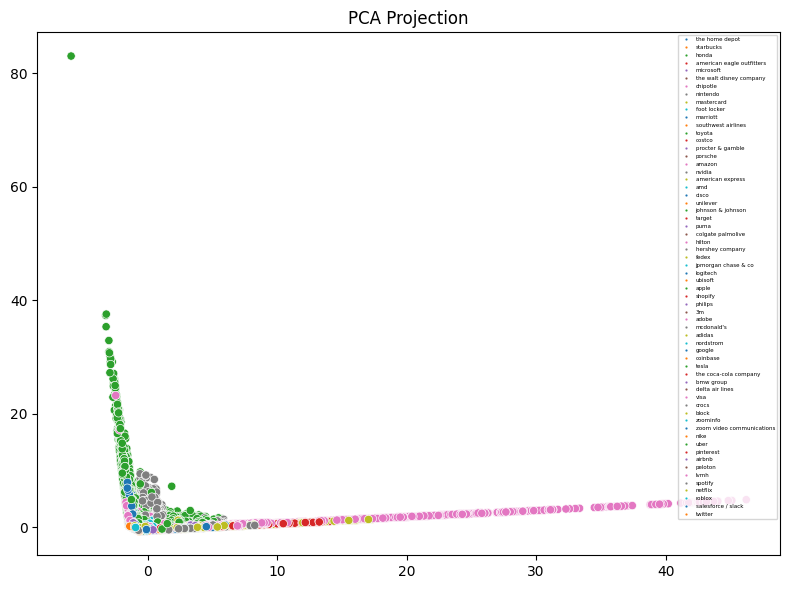

In [3]:
graphPCA(X_train, 2, Y_train)

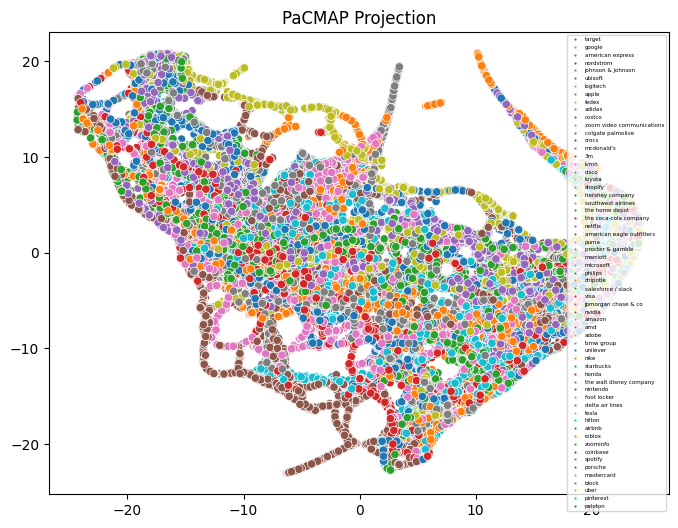

In [4]:
graphPaCMAP(X_test,Y_test)

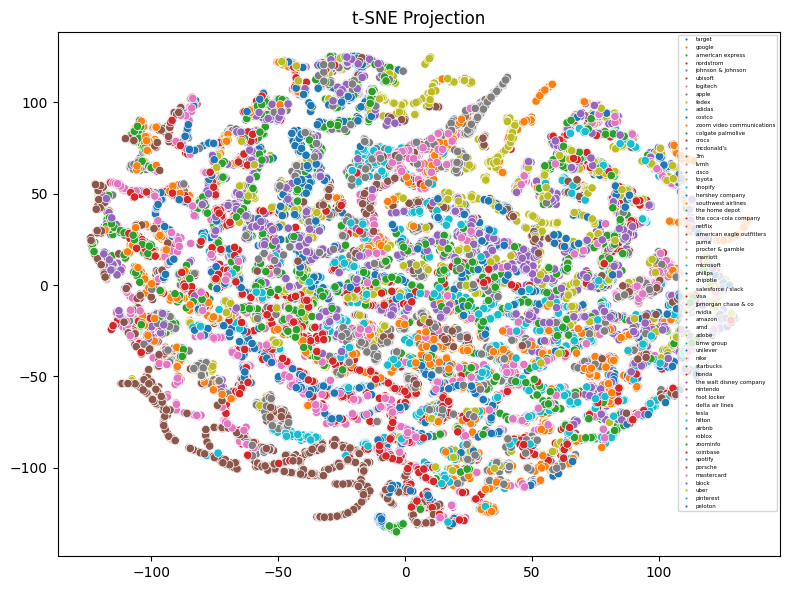

In [5]:
graphtSNE(X_test,Y_test)

/home/hootdarcy/ChE7700/che7700env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


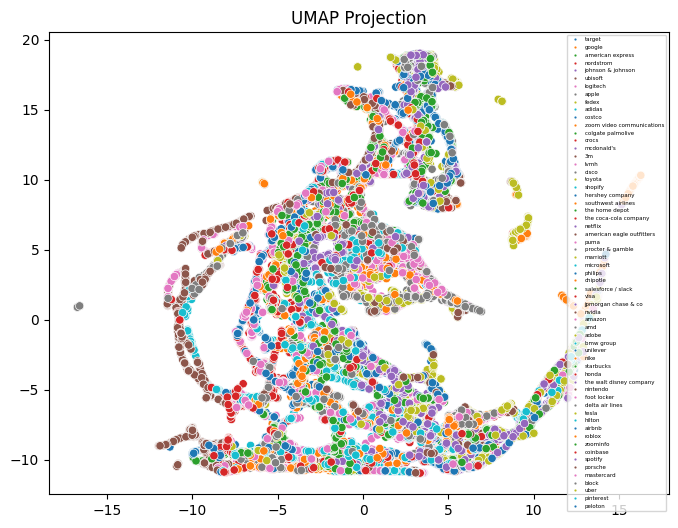

In [6]:
graphUMAP(X_test,Y_test)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

centers = 8
n_clusters = 8
df = pd.DataFrame(X_test)

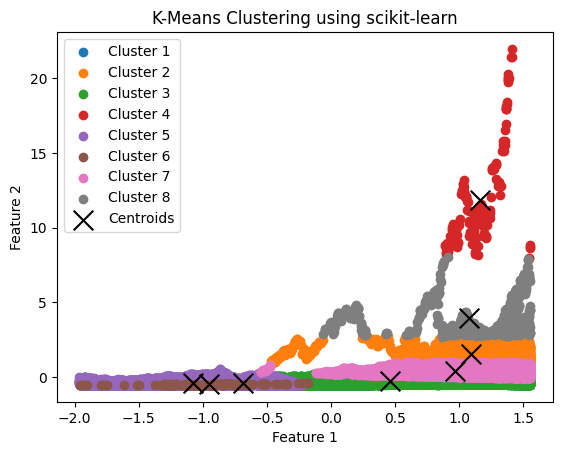

In [8]:
# Create and fit K-Means model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(df)

# Get results
labels = kmeans.labels_                 # Cluster assignment for each point
centroids = kmeans.cluster_centers_     # Final centroid positions

# Plot the clustering result
for i in range(centers):
    # Use .loc with the boolean mask and then select the desired columns
    cluster_data = df.loc[labels == i]
    plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], label=f"Cluster {i+1}")

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='x', label="Centroids")

plt.title("K-Means Clustering using scikit-learn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pacmap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from matplotlib.patches import Circle

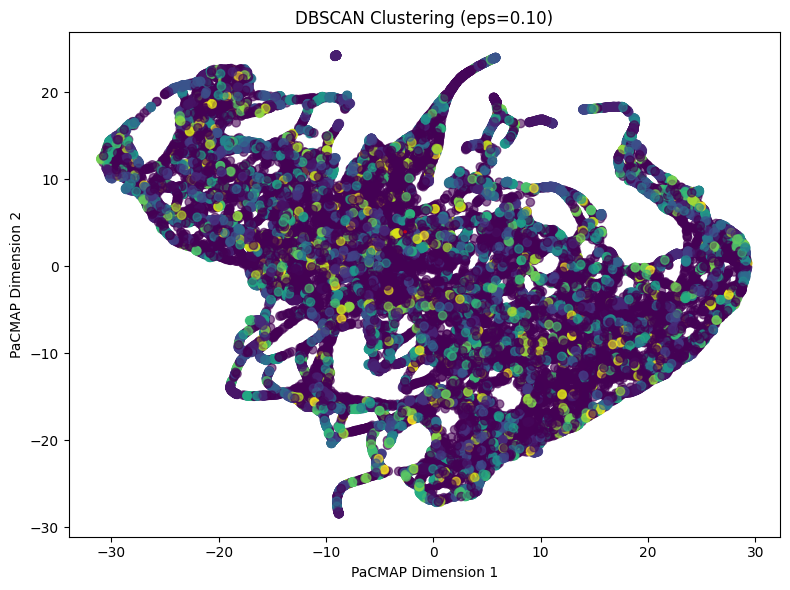

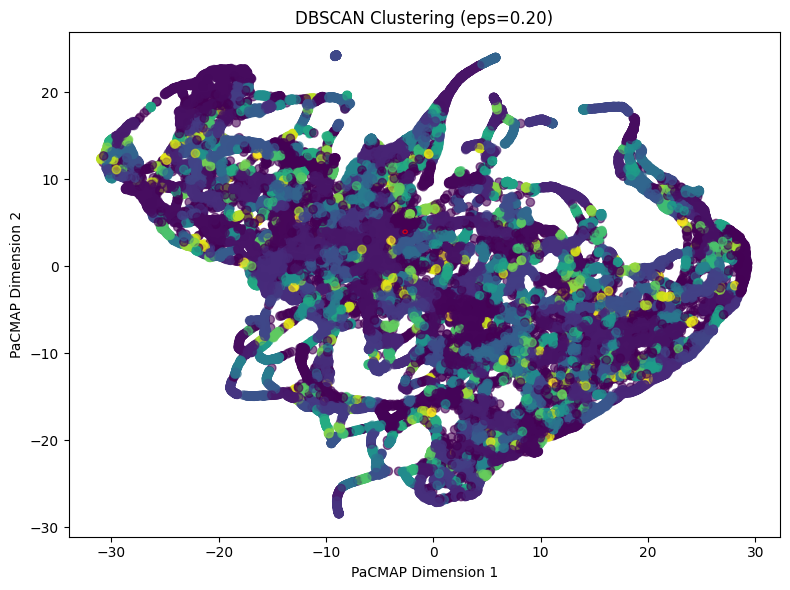

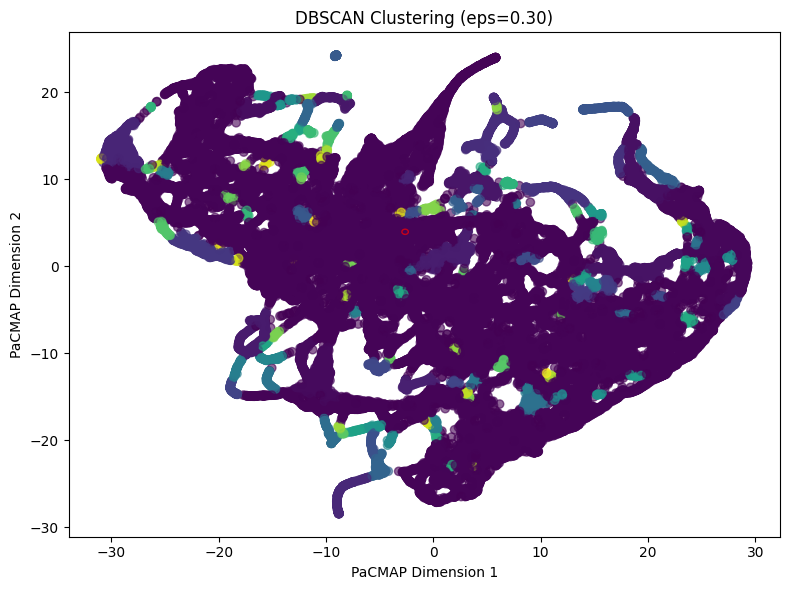

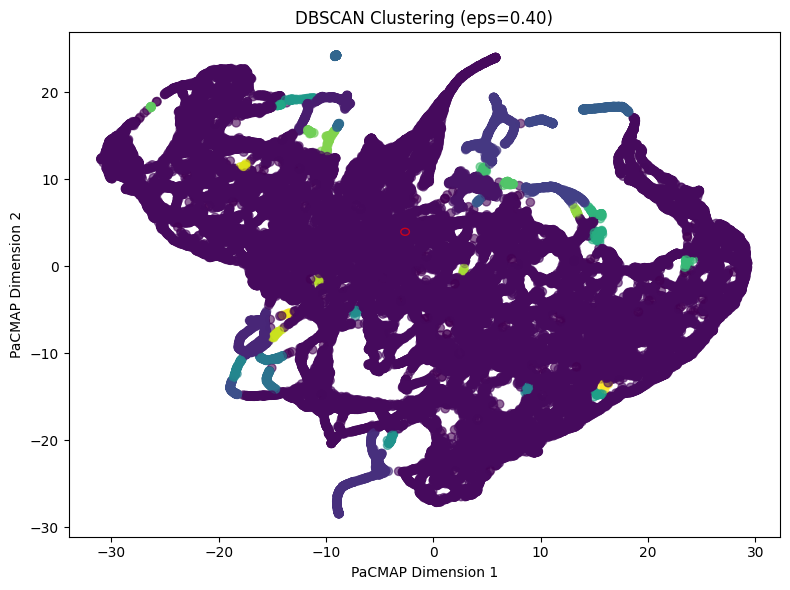

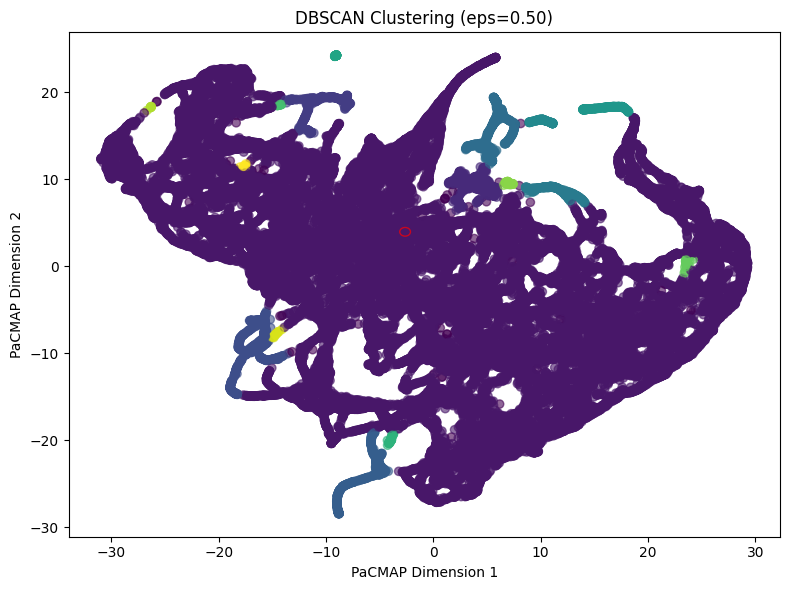

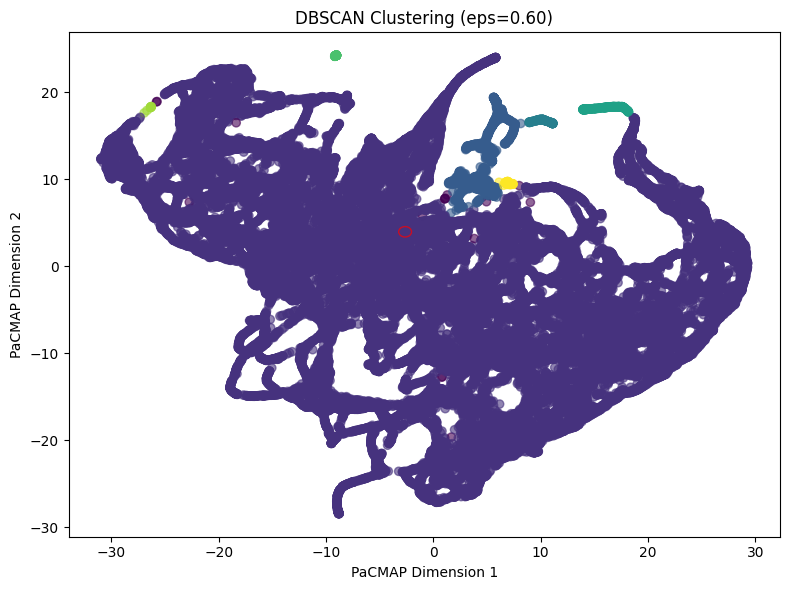

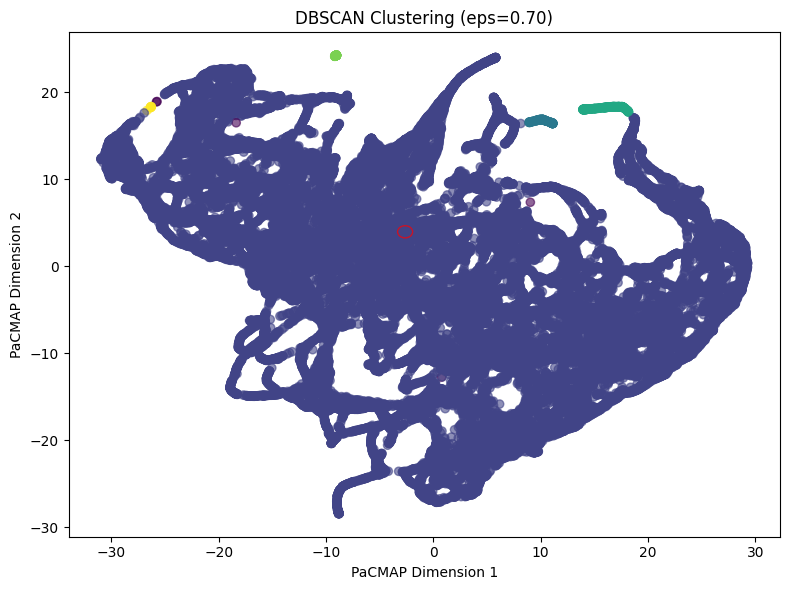

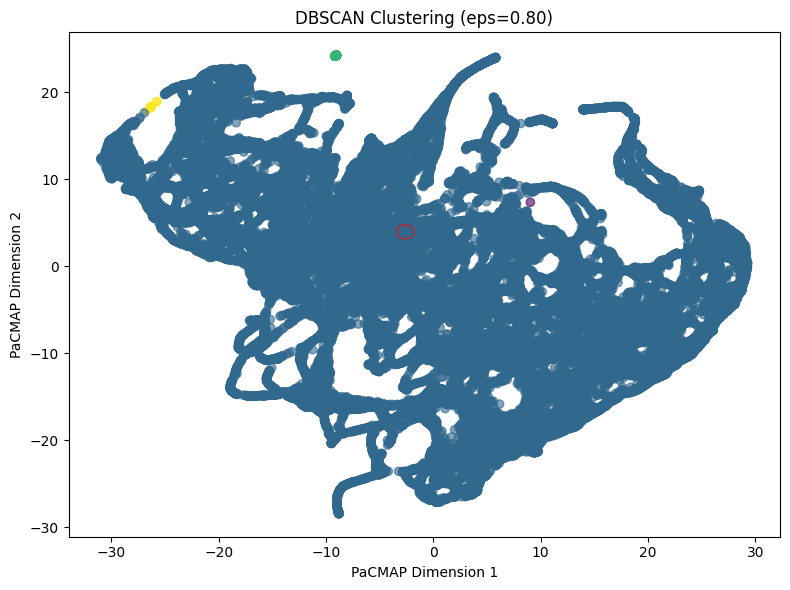

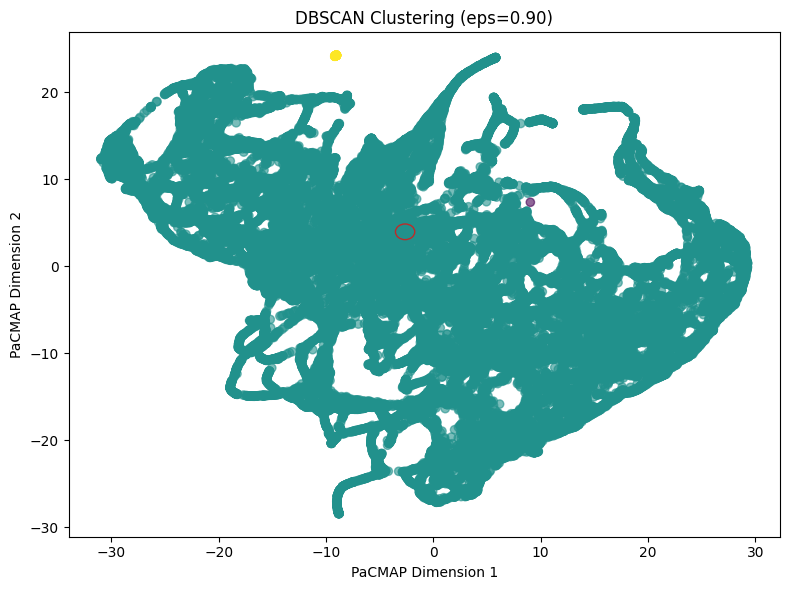

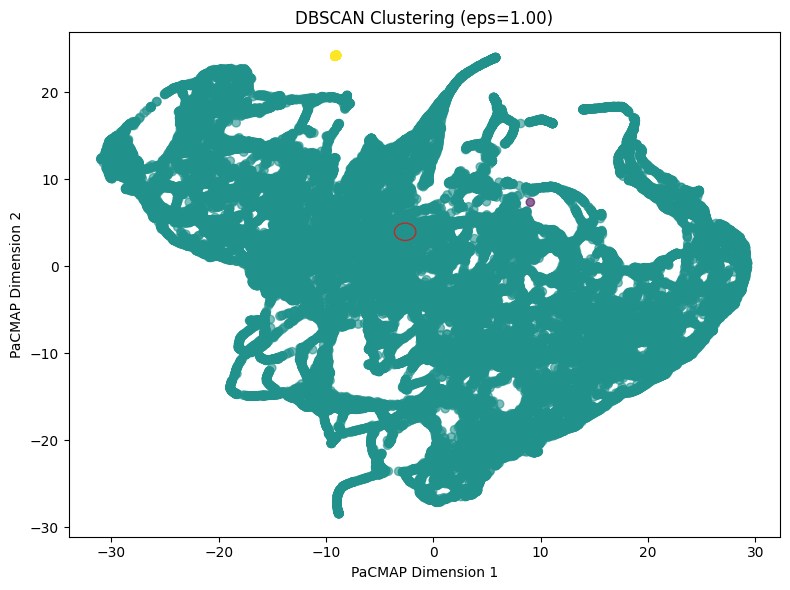

In [10]:
# Apply PaCMAP for dimensionality reduction
def apply_pacmap(data):
    reducer = pacmap.PaCMAP(n_components=2)
    return reducer.fit_transform(data)

# Plot at each iteration (no animation)
def plot_each_iteration(embedding, min_iter, max_iter, step):
    # Run DBSCAN once to pick a fixed core point (avoid noise)
    dbscan_init = DBSCAN(eps=min_iter, min_samples=5)
    labels_init = dbscan_init.fit_predict(embedding)

    core_indices = np.where(labels_init != -1)[0]
    if len(core_indices) > 0:
        fixed_index = core_indices[0]  # Choose the first core point
    else:
        fixed_index = np.random.randint(0, len(embedding))  # Fallback: pick any point if no core found

    fixed_point = embedding[fixed_index]

    for eps in np.arange(min_iter, max_iter + step, step):
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(embedding)

        plt.figure(figsize=(8, 6))
        plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", alpha=0.6)

        # Draw a single circle around the fixed core point
        circle = Circle((fixed_point[0], fixed_point[1]), eps, color="red", fill=False, alpha=0.7)
        plt.gca().add_patch(circle)

        plt.title(f"DBSCAN Clustering (eps={eps:.2f})")
        plt.xlabel("PaCMAP Dimension 1")
        plt.ylabel("PaCMAP Dimension 2")
        plt.tight_layout()
        plt.show()

#############################################################################################
# Main execution

embedding = apply_pacmap(df)

# Define DBSCAN iteration range and interval
min_iter = 0.1  # Starting eps
max_iter = 1.0  # Ending eps
step = 0.1      # Step size

plot_each_iteration(embedding, min_iter, max_iter, step)
#############################################################################################
